In [5]:
MASK = None
mask = None

## Data Loading and Shared Helpers
This section loads the exported plotting inputs and prepares the shared helper objects used by the later plotting sections.

In [6]:
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from branca.colormap import linear
from IPython.display import HTML, display

plotting_data_dir = Path("Data/PlottingData")
report_figs_dir = Path("Plots/Report_figs")
report_figs_dir.mkdir(parents=True, exist_ok=True)

monthly_counts = pd.read_csv(plotting_data_dir / "source_monthly_counts.csv", parse_dates=["month"])
edge_export = gpd.read_file(plotting_data_dir / "filtered_edge_counts_by_source.gpkg")
edge_deciles = gpd.read_file(plotting_data_dir / "edge_counts_by_source_deciles.gpkg")

te_ara_table_path = plotting_data_dir / "te_ara_table.csv"
if te_ara_table_path.exists():
    te_ara_table = pd.read_csv(te_ara_table_path)
else:
    te_ara_component_columns = [
        "strava_total_count",
        "alltrails_total_count",
        "wikiloc_total_count",
        "mobile_total_count",
    ]
    te_ara_base = edge_deciles.query("RDBPT_Sub == 'TeAra' and RDBPT_Num.notna()").copy()
    available_component_columns = [
        column for column in te_ara_component_columns if column in te_ara_base.columns
    ]
    for column in available_component_columns:
        te_ara_base[column] = pd.to_numeric(te_ara_base[column], errors="coerce").fillna(0)

    grouped = te_ara_base.groupby("RDBPT_Num", dropna=False)
    te_ara_table = grouped.size().rename("segment_count").reset_index()

    if available_component_columns:
        component_avgs = grouped[available_component_columns].mean().reset_index()
        te_ara_table = te_ara_table.merge(component_avgs, on="RDBPT_Num", how="left")
        te_ara_table["total_count"] = te_ara_table[available_component_columns].mean(axis=1)

## Timeline Plots
This section recreates the monthly timeline and month-of-year usage plots from the saved monthly counts.

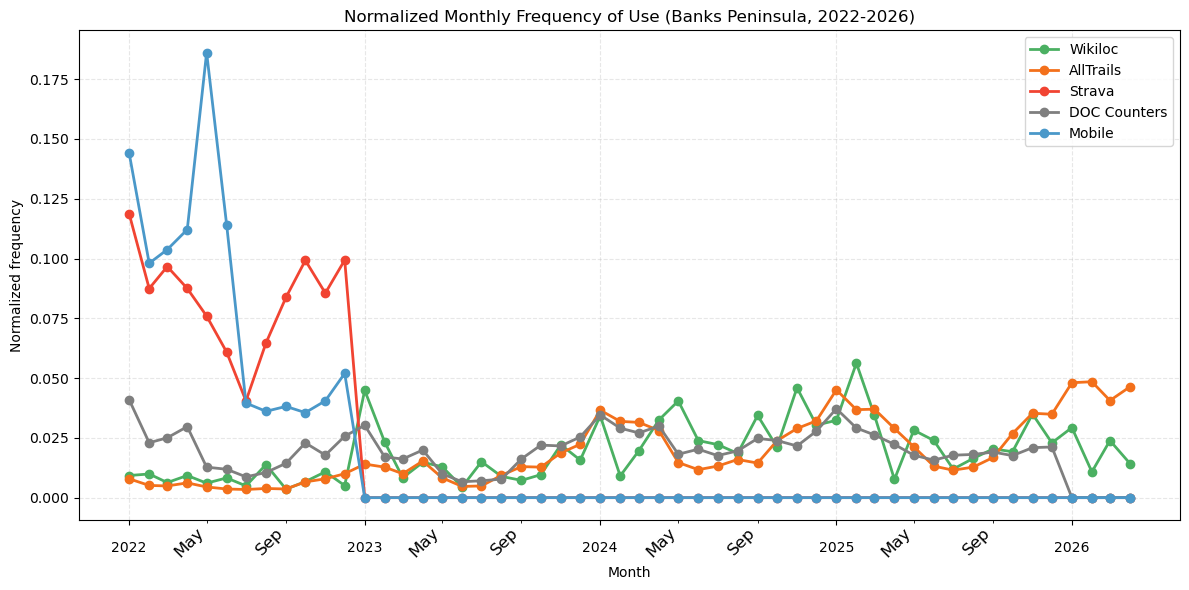

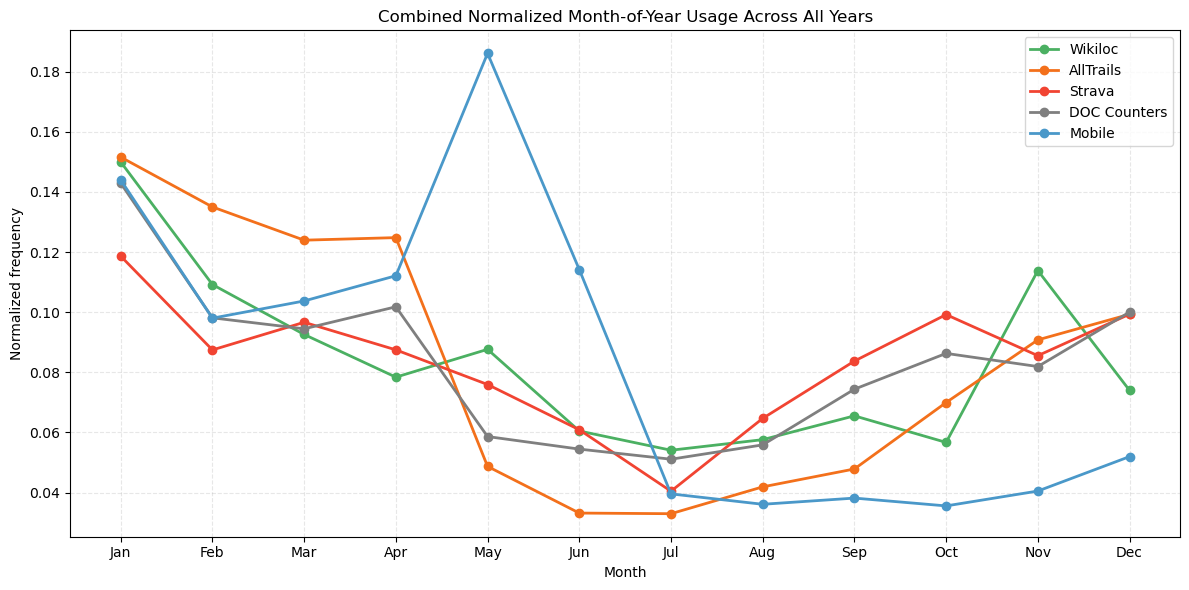

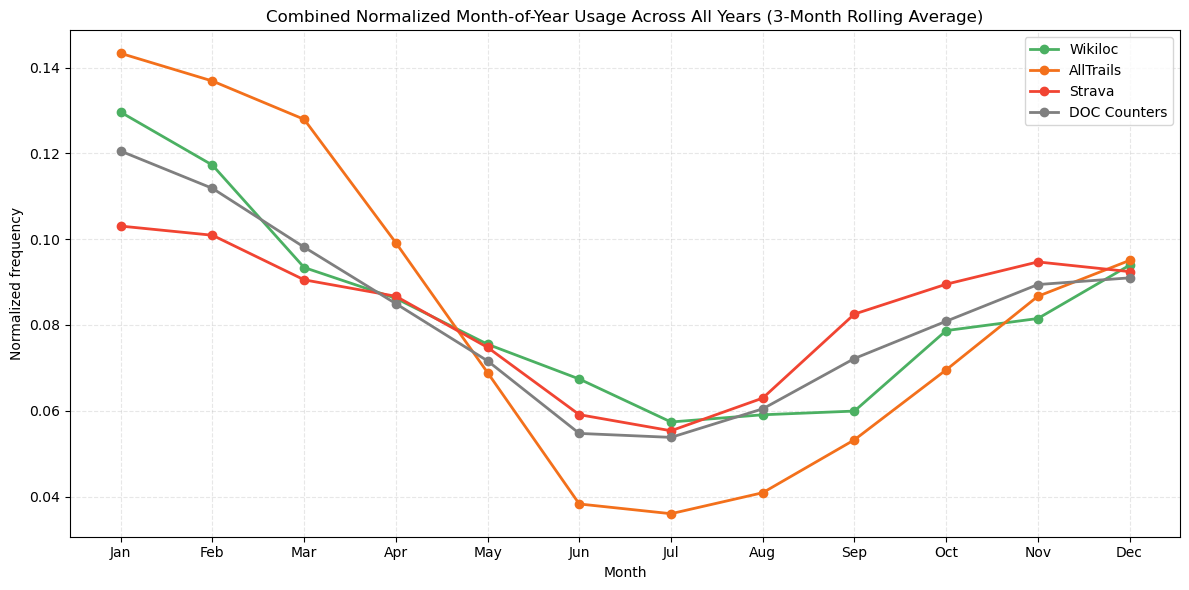

In [7]:
# Timeline and month-of-year profiles
# This section recreates the monthly timeline plot and the combined month-of-year profiles from the saved monthly counts.

colour_map = {
    "mobile": plt.get_cmap("Blues")(0.6),
    "strava": plt.get_cmap("Reds")(0.6),
    "wikiloc": plt.get_cmap("Greens")(0.6),
    "alltrails": plt.get_cmap("Oranges")(0.6),
    "doc": "#7f7f7f",
}

monthly_frame = monthly_counts.set_index("month")
months = monthly_frame.index

def normalize_series(series):
    total = series.sum()
    return series / total if total > 0 else series

wikiloc_norm = normalize_series(monthly_frame["wikiloc"])
alltrails_norm = normalize_series(monthly_frame["alltrails"])
strava_norm = normalize_series(monthly_frame["strava"])
doc_norm = normalize_series(monthly_frame["doc"])
mobile_norm = normalize_series(monthly_frame["mobile"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(months, wikiloc_norm.values, marker="o", linewidth=2, label="Wikiloc", color=colour_map["wikiloc"])
ax.plot(months, alltrails_norm.values, marker="o", linewidth=2, label="AllTrails", color=colour_map["alltrails"])
ax.plot(months, strava_norm.values, marker="o", linewidth=2, label="Strava", color=colour_map["strava"])
ax.plot(months, doc_norm.values, marker="o", linewidth=2, label="DOC Counters", color=colour_map["doc"])
ax.plot(months, mobile_norm.values, marker="o", linewidth=2, label="Mobile", color=colour_map["mobile"])
ax.set_title("Normalized Monthly Frequency of Use (Banks Peninsula, 2022-2026)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")

year_ticks = pd.date_range(months.min(), months.max(), freq="YS")
quarter_ticks = months[::4]
ax.set_xticks(year_ticks)
ax.set_xticklabels([d.strftime("%Y") for d in year_ticks])
ax.set_xticks(quarter_ticks, minor=True)
ax.set_xticklabels([d.strftime("%b") for d in quarter_ticks], minor=True, rotation=45, ha="right")
ax.tick_params(axis="x", which="major", pad=12)
ax.tick_params(axis="x", which="minor", pad=2, labelsize=12)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
fig.savefig(report_figs_dir / "timeline_monthly_normalized.svg", format="svg", bbox_inches="tight")
fig.savefig(report_figs_dir / "timeline_monthly_normalized.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

month_numbers = pd.Index(range(1, 13), name="month")
month_labels = [pd.Timestamp(2000, month, 1).strftime("%b") for month in month_numbers]
monthly_by_month = monthly_frame.groupby(monthly_frame.index.month).sum().reindex(range(1, 13), fill_value=0)

def month_profile(monthly_series):
    total = monthly_series.sum()
    normalized = monthly_series / total if total > 0 else monthly_series.astype(float)
    normalized_roll3 = normalized.rolling(3, center=True, min_periods=1).mean()
    return normalized, normalized_roll3

wikiloc_by_month_norm, wikiloc_by_month_norm_roll3 = month_profile(monthly_by_month["wikiloc"])
alltrails_by_month_norm, alltrails_by_month_norm_roll3 = month_profile(monthly_by_month["alltrails"])
strava_by_month_norm, strava_by_month_norm_roll3 = month_profile(monthly_by_month["strava"])
doc_by_month_norm, doc_by_month_norm_roll3 = month_profile(monthly_by_month["doc"])
mobile_by_month_norm, mobile_by_month_norm_roll3 = month_profile(monthly_by_month["mobile"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm.values, marker="o", linewidth=2, label="Wikiloc", color=colour_map["wikiloc"])
ax.plot(month_labels, alltrails_by_month_norm.values, marker="o", linewidth=2, label="AllTrails", color=colour_map["alltrails"])
ax.plot(month_labels, strava_by_month_norm.values, marker="o", linewidth=2, label="Strava", color=colour_map["strava"])
ax.plot(month_labels, doc_by_month_norm.values, marker="o", linewidth=2, label="DOC Counters", color=colour_map["doc"])
ax.plot(month_labels, mobile_by_month_norm.values, marker="o", linewidth=2, label="Mobile", color=colour_map["mobile"])
ax.set_title("Combined Normalized Month-of-Year Usage Across All Years")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
fig.savefig(report_figs_dir / "month_of_year_profile.svg", format="svg", bbox_inches="tight")
fig.savefig(report_figs_dir / "month_of_year_profile.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(month_labels, wikiloc_by_month_norm_roll3.values, marker="o", linewidth=2, label="Wikiloc", color=colour_map["wikiloc"])
ax.plot(month_labels, alltrails_by_month_norm_roll3.values, marker="o", linewidth=2, label="AllTrails", color=colour_map["alltrails"])
ax.plot(month_labels, strava_by_month_norm_roll3.values, marker="o", linewidth=2, label="Strava", color=colour_map["strava"])
ax.plot(month_labels, doc_by_month_norm_roll3.values, marker="o", linewidth=2, label="DOC Counters", color=colour_map["doc"])
ax.set_title("Combined Normalized Month-of-Year Usage Across All Years (3-Month Rolling Average)")
ax.set_xlabel("Month")
ax.set_ylabel("Normalized frequency")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
fig.savefig(report_figs_dir / "month_of_year_profile_rolling3.svg", format="svg", bbox_inches="tight")
fig.savefig(report_figs_dir / "month_of_year_profile_rolling3.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

## Edge Heatmaps
This section draws the source-specific and combined edge heatmaps using the saved edge export and shared plotting helper.

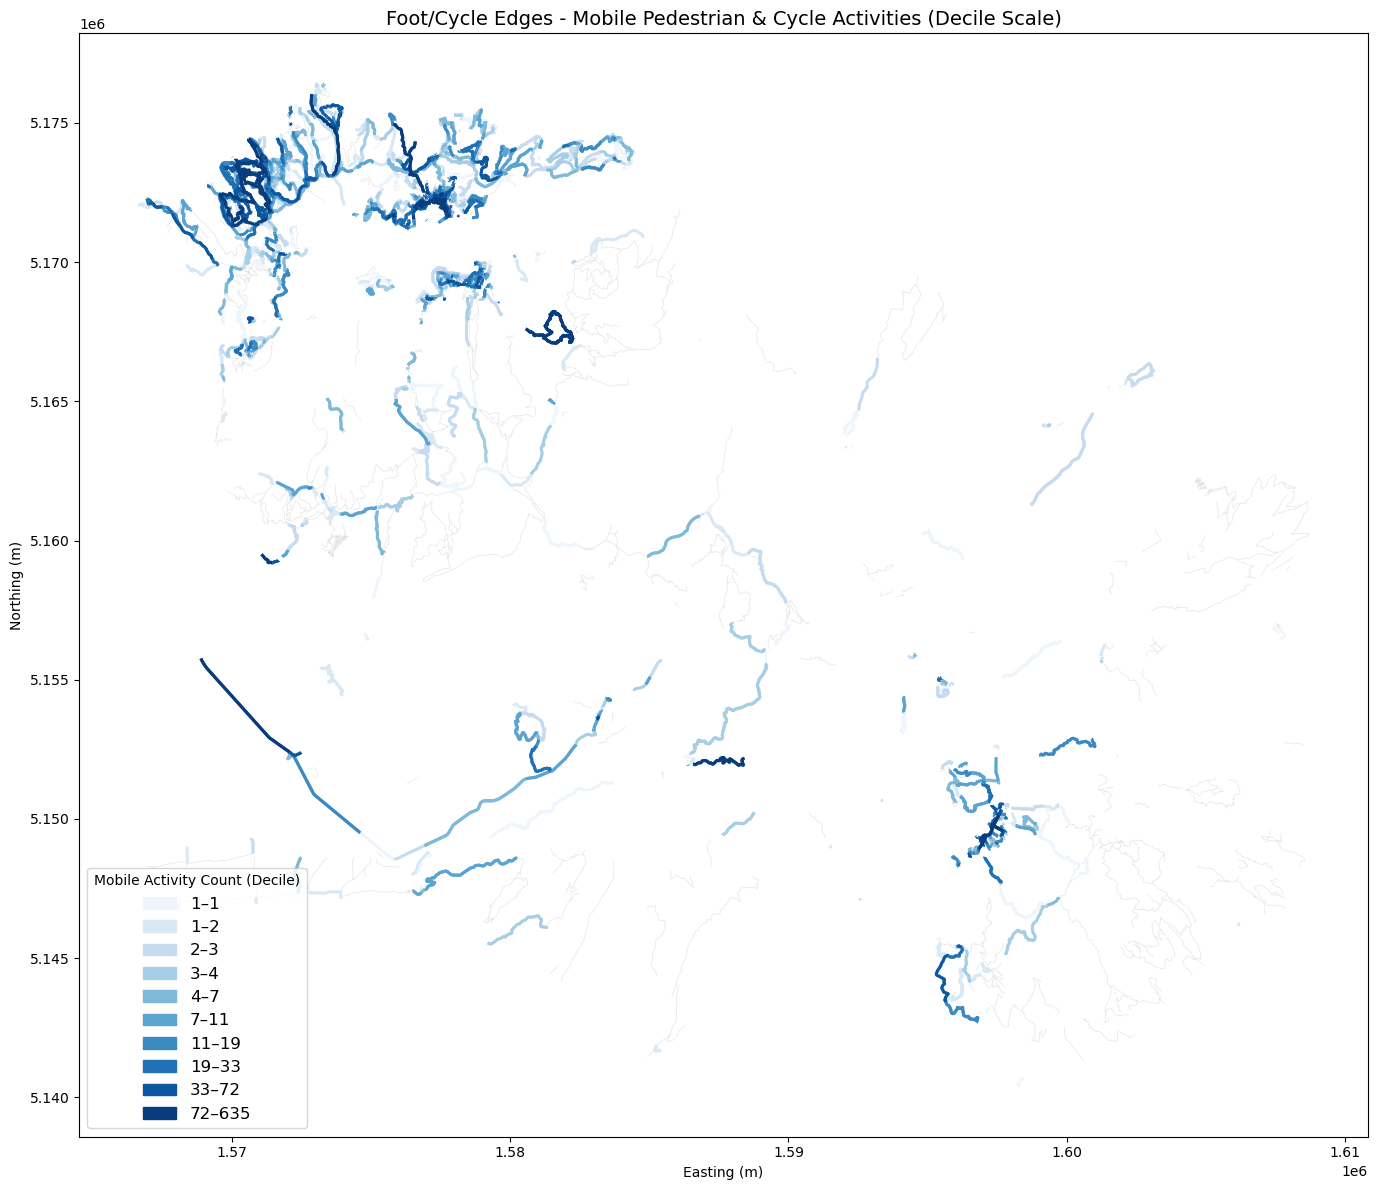

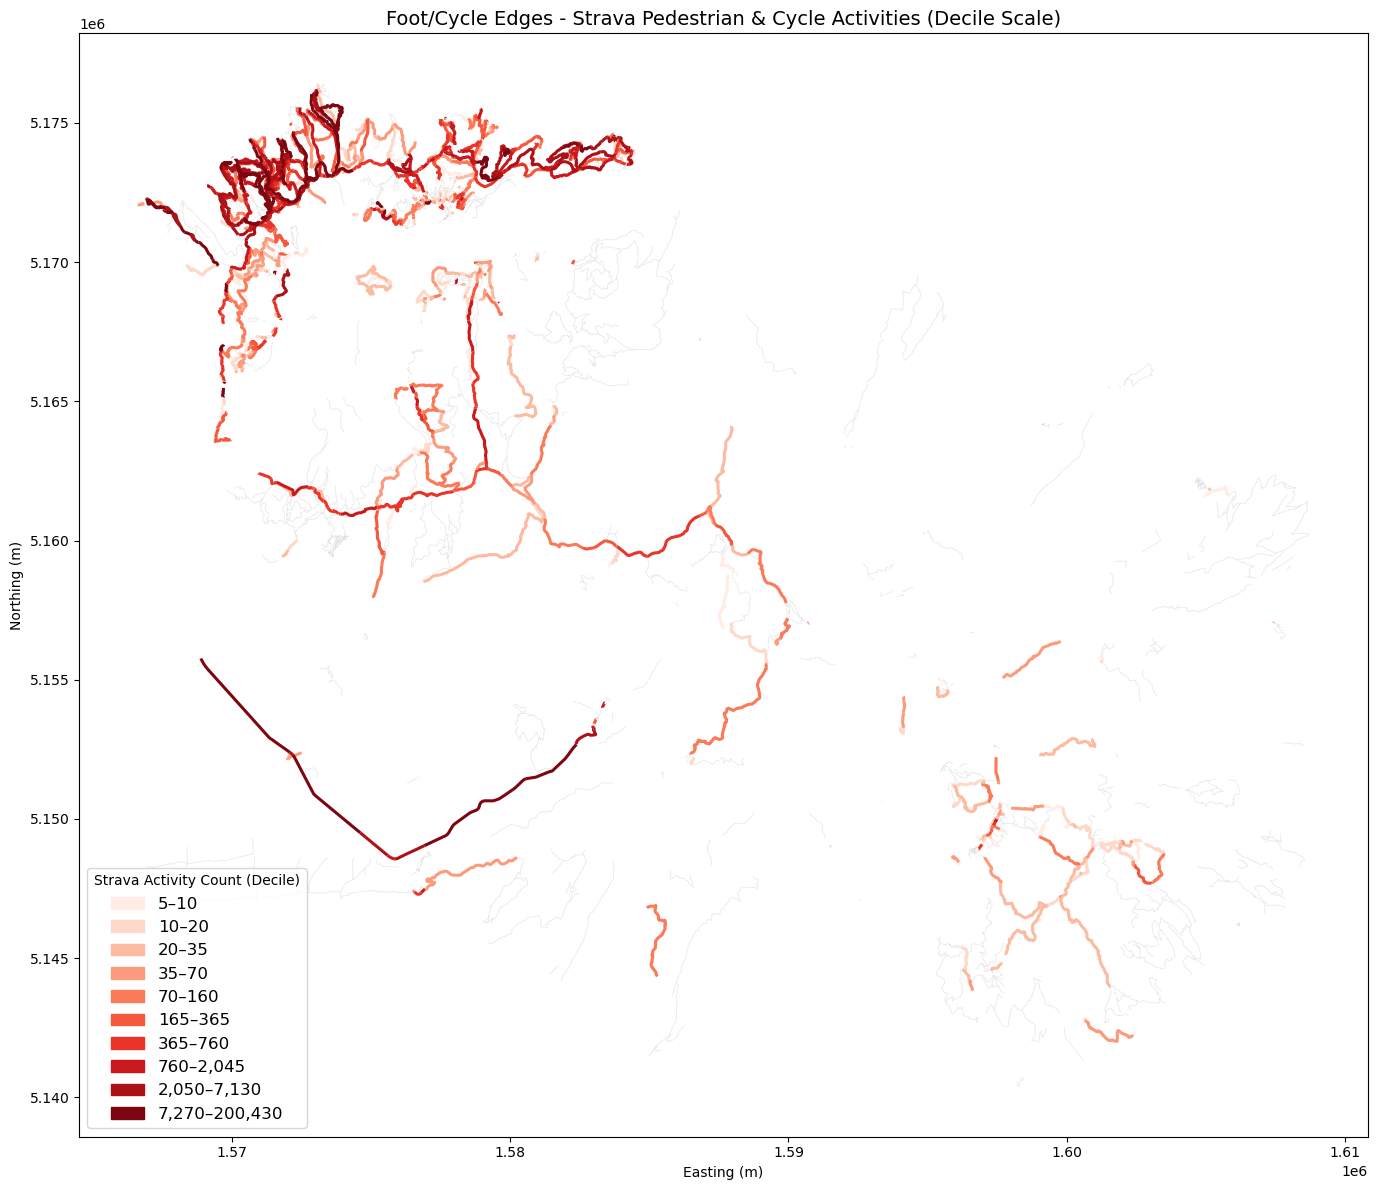

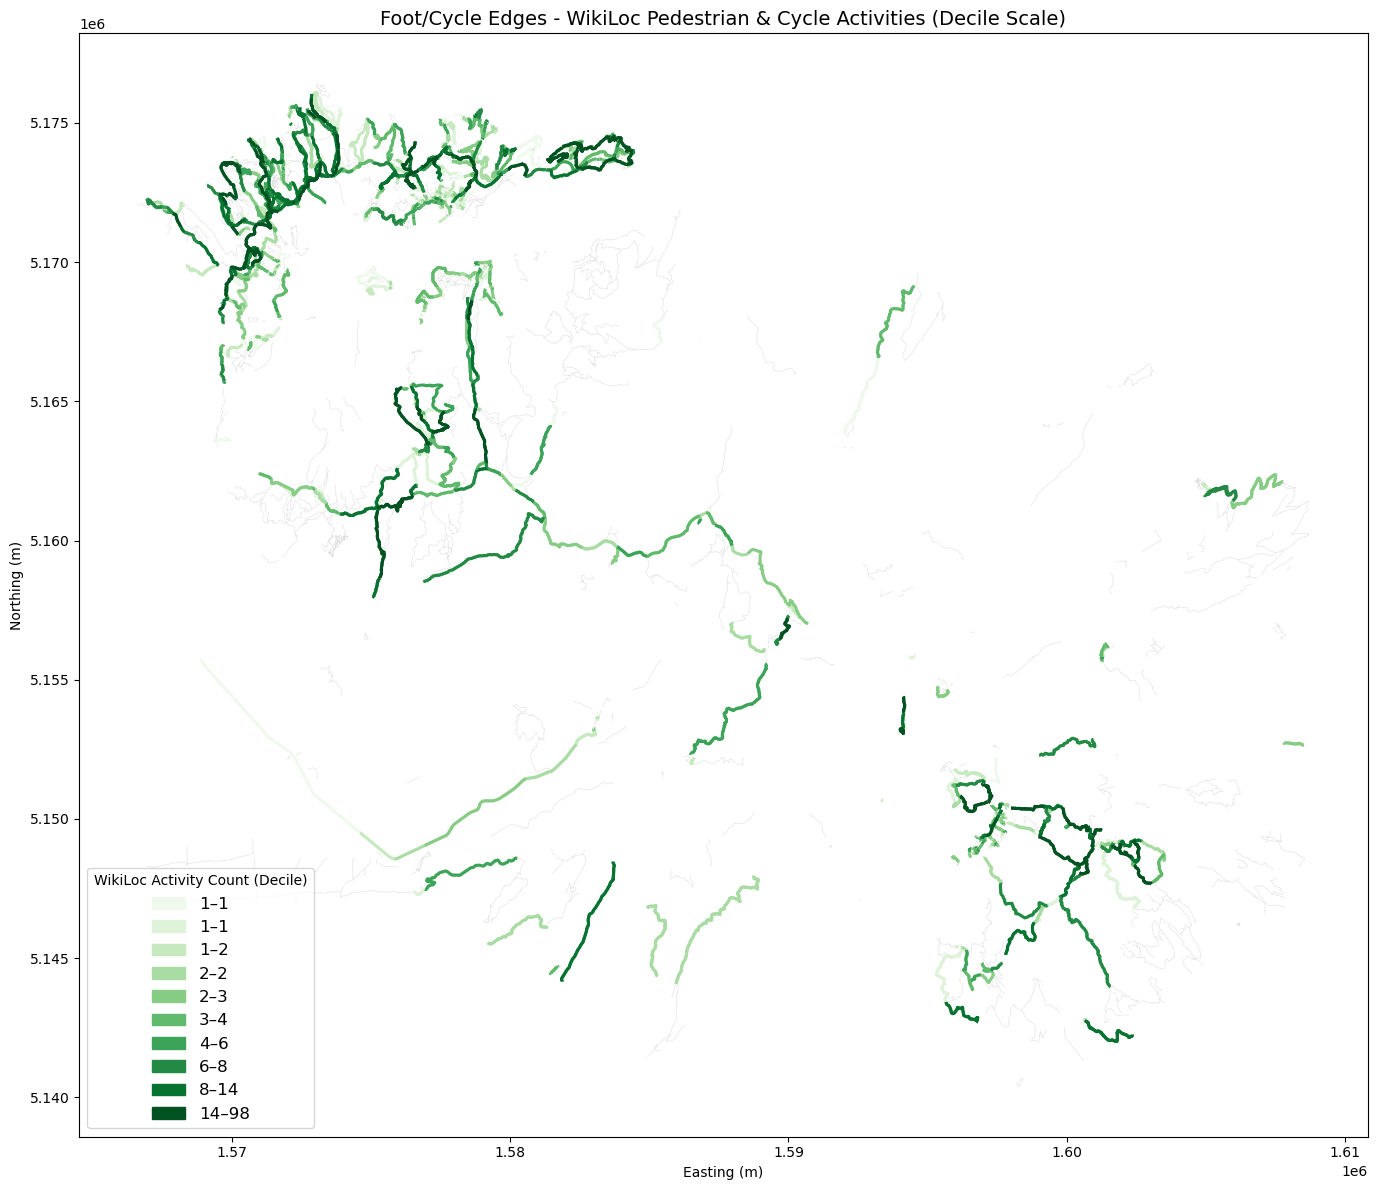

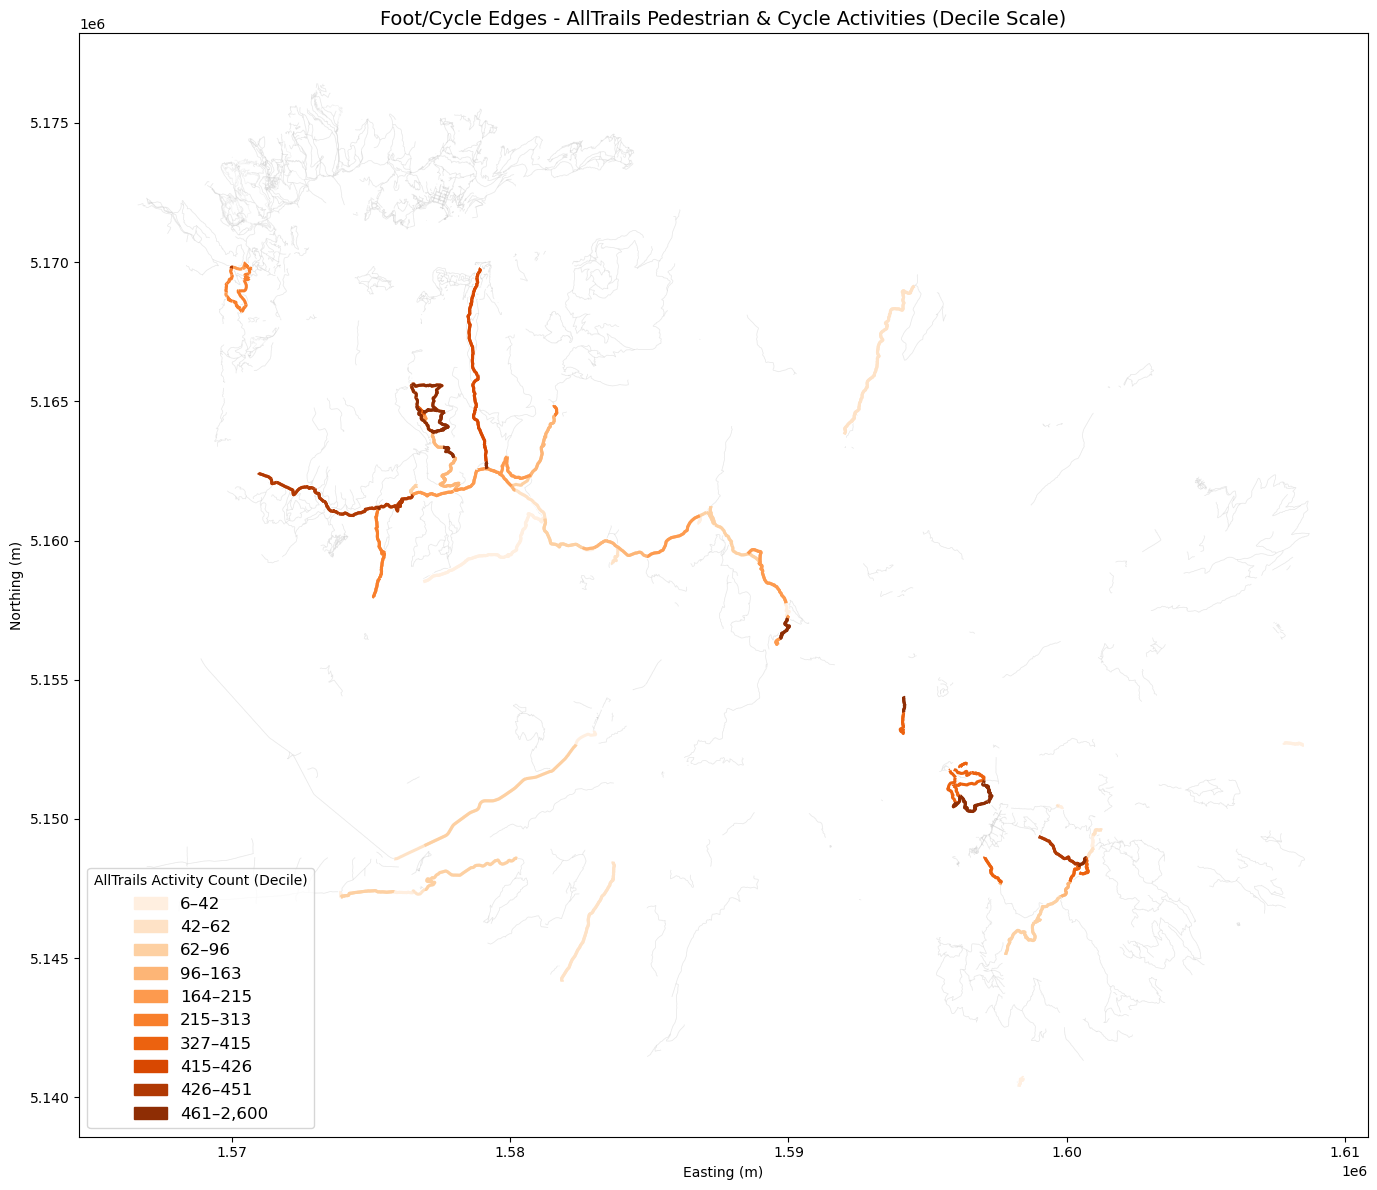

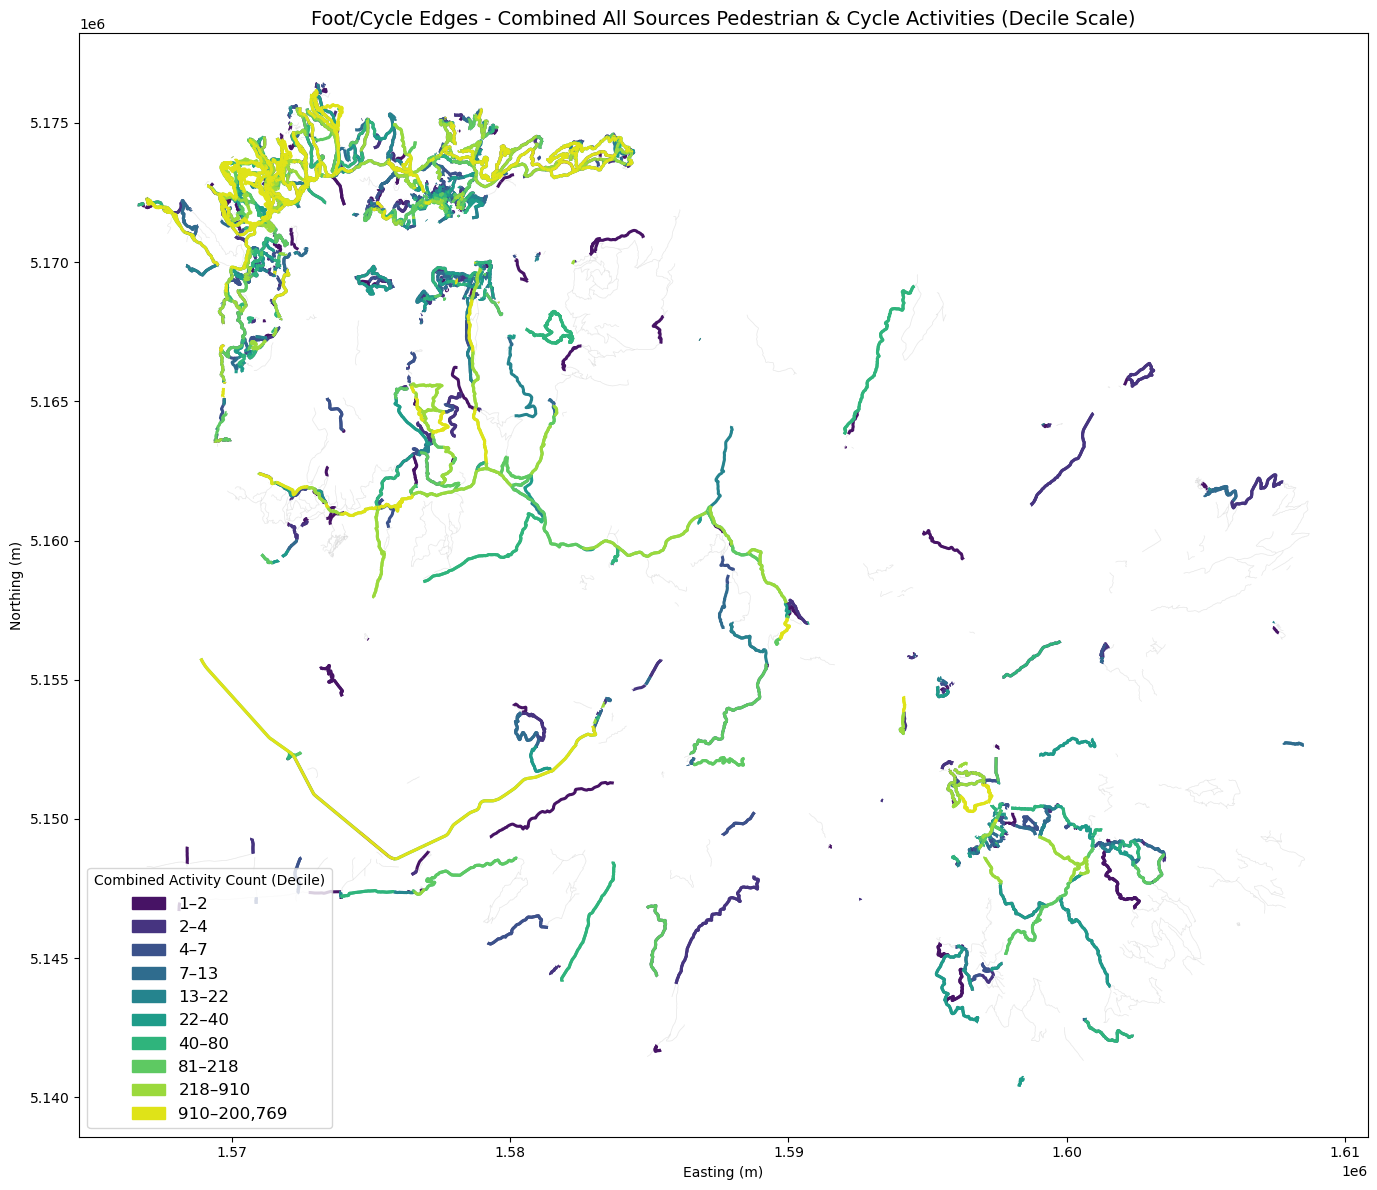

: 

In [ ]:
# Edge heatmaps
# This section renders the source-specific and combined edge heatmaps from the exported edge counts.

def plot_edge_heatmap(edges_gdf, count_column, title, cmap, legend_label, debug=False):
    edges_with_counts = edges_gdf.copy()
    edges_with_counts["activity_count"] = pd.to_numeric(edges_with_counts[count_column], errors="coerce").fillna(0)
    active_edges = edges_with_counts[edges_with_counts["activity_count"] > 0]
    inactive_edges = edges_with_counts[edges_with_counts["activity_count"] == 0]

    fig, ax = plt.subplots(figsize=(14, 12))
    edge_mask = None
    if "MASK" in globals():
        edge_mask = MASK
    elif "mask" in globals():
        edge_mask = mask

    if edge_mask is not None:
        edge_mask.boundary.plot(ax=ax, color="black", linewidth=1.5, zorder=0)

    if len(inactive_edges) > 0:
        inactive_edges.plot(ax=ax, linewidth=0.5, color="lightgrey", alpha=0.3, zorder=1)

    if len(active_edges) > 0:
        counts = active_edges["activity_count"].astype(float)
        n = len(counts)

        if debug:
            print("DEBUG: active_edges count=", n)
            print("DEBUG: counts min/max/unique:", counts.min(), counts.max(), counts.nunique())

        try:
            cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
        except Exception:
            cmap_obj = plt.get_cmap("viridis")

        if counts.nunique() == 1:
            color = cmap_obj(0.6)
            active_edges.plot(ax=ax, color=[mpl.colors.to_hex(color)] * len(active_edges), linewidth=2.6, alpha=1.0, zorder=3)
            ax.set_title(f"{title} — all edges = {int(counts.iloc[0]):,}", fontsize=14)
        else:
            n_bins = min(10, n)
            ranks = counts.rank(method="first").astype(int)
            bin_idx = ((ranks - 1) * n_bins) // n
            bin_idx = bin_idx.astype(int)
            palette = cmap_obj(np.linspace(0.05, 0.95, n_bins))
            patches = []

            for i in range(n_bins):
                idx = bin_idx[bin_idx == i].index
                if len(idx) == 0:
                    continue
                group = active_edges.loc[idx]
                colour = mpl.colors.to_hex(palette[i])
                group.plot(ax=ax, color="#ffffff", linewidth=3.6, alpha=1.0, zorder=2)
                group.plot(ax=ax, color=colour, linewidth=2.2, alpha=1.0, zorder=3)
                group_counts = counts.loc[idx]
                label = f"{int(group_counts.min()):,}–{int(group_counts.max()):,}"
                patches.append(mpatches.Patch(color=colour, label=label))

            if patches:
                ax.legend(handles=patches, title=legend_label, loc="lower left", fontsize=12)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()

plot_edge_heatmap(
    edge_export,
    "mobile_total_count",
    "Foot/Cycle Edges - Mobile Pedestrian & Cycle Activities (Decile Scale)",
    "Blues",
    "Mobile Activity Count (Decile)",
)

plot_edge_heatmap(
    edge_export,
    "strava_total_count",
    "Foot/Cycle Edges - Strava Pedestrian & Cycle Activities (Decile Scale)",
    "Reds",
    "Strava Activity Count (Decile)",
)

plot_edge_heatmap(
    edge_export,
    "wikiloc_total_count",
    "Foot/Cycle Edges - WikiLoc Pedestrian & Cycle Activities (Decile Scale)",
    "Greens",
    "WikiLoc Activity Count (Decile)",
)

plot_edge_heatmap(
    edge_export,
    "alltrails_total_count",
    "Foot/Cycle Edges - AllTrails Pedestrian & Cycle Activities (Decile Scale)",
    "Oranges",
    "AllTrails Activity Count (Decile)",
)

plot_edge_heatmap(
    edge_export,
    "total_count",
    "Foot/Cycle Edges - Combined All Sources Pedestrian & Cycle Activities (Decile Scale)",
    "viridis",
    "Combined Activity Count (Decile)",
)

## Te Ara Summary Table
This section turns the saved Te Ara counts into a styled summary table and exports presentation-friendly versions.

In [ ]:
# Te Ara summary table
# This section formats the saved Te Ara counts and writes HTML, CSV, and Excel outputs for the report figures folder.

te_ara_display_columns = [column for column in te_ara_table.columns if column != "RDBPT_Num"]
styled_te_ara_table = te_ara_table.style.format({
    "segment_count": "{:,}",
    **{column: "{:.2f}" for column in te_ara_display_columns if column != "segment_count"},
})

column_cmaps = {
    "mobile_total_count": "Blues",
    "strava_total_count": "Reds",
    "wikiloc_total_count": "Greens",
    "alltrails_total_count": "Oranges",
}

for column_name, cmap_name in column_cmaps.items():
    if column_name in te_ara_table.columns:
        styled_te_ara_table = styled_te_ara_table.background_gradient(cmap=cmap_name, subset=[column_name])

if "total_count" in te_ara_table.columns:
    styled_te_ara_table = styled_te_ara_table.background_gradient(cmap="viridis", subset=["total_count"])

styled_te_ara_table = styled_te_ara_table.set_caption("Te Ara top-group average deciles by RDBPT_Num")
display(styled_te_ara_table)
styled_te_ara_table.to_html(report_figs_dir / "te_ara_decile_table.html")
te_ara_table.to_csv(report_figs_dir / "te_ara_decile_table.csv", index=False, encoding="utf-8-sig")
te_ara_table.to_excel(report_figs_dir / "te_ara_decile_table.xlsx", index=False)

styled_te_ara_table._compute()
table_fig, table_ax = plt.subplots(figsize=(max(12, len(te_ara_table.columns) * 1.25), max(4, 0.35 * (len(te_ara_table) + 2))))
table_ax.axis("off")
table_render = table_ax.table(
    cellText=te_ara_table.astype(str).values,
    colLabels=te_ara_table.columns.tolist(),
    loc="center",
)

for (row_idx, col_idx), cell in table_render.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor("#d9d9d9")
        cell.set_text_props(weight="bold", color="black")
    else:
        style_items = dict(styled_te_ara_table.ctx.get((row_idx - 1, col_idx), []))
        if "background-color" in style_items:
            cell.set_facecolor(style_items["background-color"])
        if "color" in style_items:
            cell.get_text().set_color(style_items["color"])
        cell.set_edgecolor("white")

table_render.auto_set_font_size(False)
table_render.set_fontsize(12)
table_render.scale(1, 1.35)
table_fig.savefig(report_figs_dir / "te_ara_decile_table.svg", format="svg", bbox_inches="tight")
table_fig.savefig(report_figs_dir / "te_ara_decile_table.pdf", format="pdf", bbox_inches="tight")
plt.close(table_fig)

,RDBPT_Num,segment_count
0,1,88
1,10,24
2,11,28
3,12,32
4,13,4
5,14,14
6,2,12
7,3,20
8,4,2
9,5,50


## Interactive Map
This section builds the decile-based Folium map from the saved plotting inputs and exports the HTML version for sharing.

In [ ]:
count_columns = [
    ("mobile_pedestrian_decile", "Mobile pedestrian decile"),
    ("mobile_cycle_decile", "Mobile cycle decile"),
    ("mobile_total_decile", "Mobile total decile"),
    ("strava_pedestrian_decile", "Strava pedestrian decile"),
    ("strava_cycle_decile", "Strava cycle decile"),
    ("strava_total_decile", "Strava total decile"),
    ("wikiloc_pedestrian_decile", "Wikiloc pedestrian decile"),
    ("wikiloc_cycle_decile", "Wikiloc cycle decile"),
    ("wikiloc_total_decile", "Wikiloc total decile"),
    ("alltrails_pedestrian_decile", "AllTrails pedestrian decile"),
    ("alltrails_cycle_decile", "AllTrails cycle decile"),
    ("alltrails_total_decile", "AllTrails total decile"),
    ("total_pedestrian_decile", "Overall pedestrian decile"),
    ("total_cycle_decile", "Overall cycle decile"),
    ("total_decile", "Overall total decile"),
]

def make_style_fn(value_column, colormap):
    def style_fn(feature):
        value = feature["properties"].get(value_column)
        if value is None:
            return {"color": "#9e9e9e", "weight": 2, "opacity": 0.55}
        return {"color": colormap(value), "weight": 3, "opacity": 0.85}

    return style_fn

minx, miny, maxx, maxy = edge_deciles.to_crs(4326).total_bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

gdf = edge_deciles.to_crs(4326)
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles="CartoDB dark_matter",
    control_scale=True,
)
m.fit_bounds([[miny, minx], [maxy, maxx]])

tooltip_fields = [field for field in ["name"] if field in gdf.columns]

for value_column, layer_name in count_columns:
    if value_column not in gdf.columns:
        continue

    min_value = float(gdf[value_column].min())
    max_value = float(gdf[value_column].max())
    colormap = linear.YlOrRd_09.scale(min_value, max_value)
    layer_gdf = gdf.sort_values(value_column, ascending=True, na_position="first", kind="mergesort")

    layer = folium.FeatureGroup(name=layer_name, show=value_column == "total_decile")
    geojson = folium.GeoJson(
        layer_gdf,
        style_function=make_style_fn(value_column, colormap),
        highlight_function=lambda feature: {
            "weight": 6,
            "opacity": 1.0,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields + [value_column],
            aliases=["Name", layer_name] if tooltip_fields else [layer_name],
            localize=True,
            sticky=False,
        ),
    )
    geojson.add_to(layer)
    layer.add_to(m)

legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    z-index: 9999;
    background-color: rgba(255, 255, 255, 0.92);
    border: 1px solid #999;
    border-radius: 6px;
    padding: 10px 12px;
    font-size: 12px;
    line-height: 1.2;
    box-shadow: 0 1px 4px rgba(0, 0, 0, 0.2);
>
    <div style="font-weight: 700; margin-bottom: 6px;">
        Track Segment Popularity by Decile
    </div>
    <div style="
        width: 180px;
        height: 12px;
        background: linear-gradient(to right, #ffffcc, #800026);
        border: 1px solid #999;
        margin-bottom: 4px;
    "></div>
    <div style="display: flex; justify-content: space-between; width: 180px;">
        <span>Low</span>
        <span>High</span>
    </div>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)
html_path = report_figs_dir / "edge_deciles_interactive_dark.html"
m.save(str(html_path))
display(HTML(f'<a href="{html_path.resolve().as_uri()}" target="_blank">Open interactive HTML map</a>'))
print(f"Saved interactive map to: {html_path.resolve()}")